# Hierarchical clustering builds a tree of clusters (called a dendrogram).

## Two main types:

## Agglomerative (bottom-up) → start with each point as its own cluster, then merge
## Divisive (top-down) → start with one cluster, then split

### Most commonly used: Agglomerative

Key idea:

At each step, merge the closest clusters

“Closeness” depends on linkage method:
    Single linkage → closest points
    Complete linkage → farthest points
    Average linkage → average distance
    Ward linkage → minimizes variance (most popular)

In [ ]:
# Agglomerative Clustering
Bottom-Up: Agglomerative Clustering (most common)

1. Starts with each data point as its own cluster
2. Iteratively merges the closest pairs of clusters
3. Continues until all points belong to one big cluster

Think of it like building a pyramid from bricks — you start from the bottom and merge upward.

[1] [2] [3] [4]
 => [1 2] [3] [4]
 => [1 2] [3 4]
 => [1 2 3 4]


In [ ]:
# Divise Clustering 

Instead of merging small clusters (like agglomerative), we Start with all data in ONE cluster → keep splitting it

1. Starts with all points in one cluster
2. Recursively splits the cluster into smaller parts
3. Continues until each point is its own cluster or a stopping condition is met

Think of it like chopping a big tree down into branches
[1 2 3 4]
 => [1 2] [3 4]
 => [1] [2] [3 4]
 => [1] [2] [3] [4]


In [ ]:
| Feature           | K-Means       | Hierarchical      |
| ----------------- | ------------- | ----------------- |
| Need K beforehand | Yes           |  No               |
| Speed             | Fast          |  Slow             |
| Scalability       | High          | Low               |
| Interpretability  | Medium        | High (dendrogram) |
| Structure         | Flat clusters | Tree structure    |


In [ ]:
SIMPLE ANALOGY:

K-Means
→ “I want exactly 3 groups. Now fit data into 3 buckets.”
Hierarchical
→ “Let me see how everything is related first… then I’ll decide how many groups make sense.”

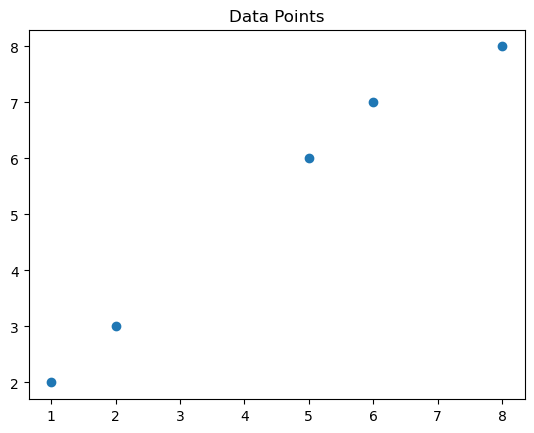

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([
    [1, 2],
    [2, 3],
    [5, 6],
    [6, 7],
    [8, 8]
])

# Plot data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Data Points")
plt.show()

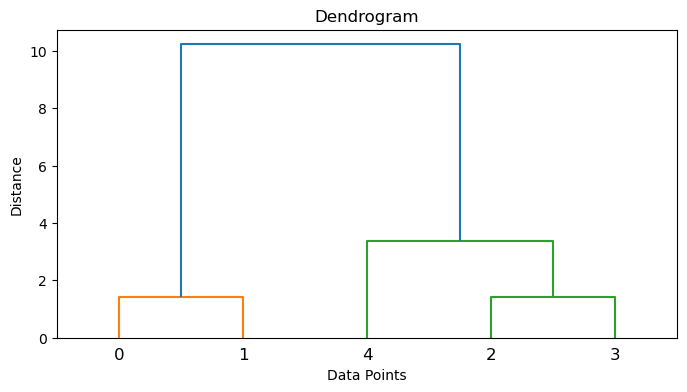

In [2]:
# Build Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
Each merge = combining two clusters
Height of merge = distance between clusters
To choose clusters → draw a horizontal line

In [3]:
from scipy.cluster.hierarchy import fcluster

# Form 2 clusters
clusters = fcluster(Z, t=2, criterion='maxclust')

print(clusters)

[1 1 2 2 2]


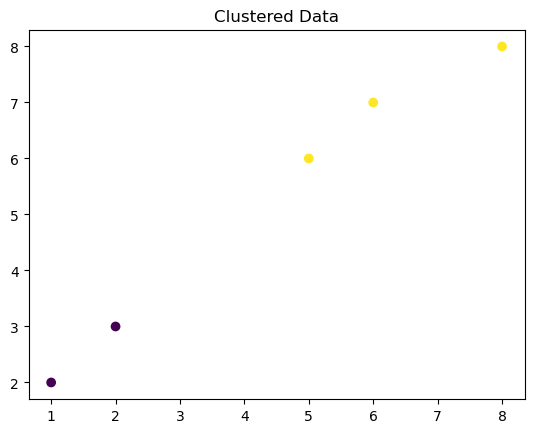

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.title("Clustered Data")
plt.show()

In [ ]:
# Complete 

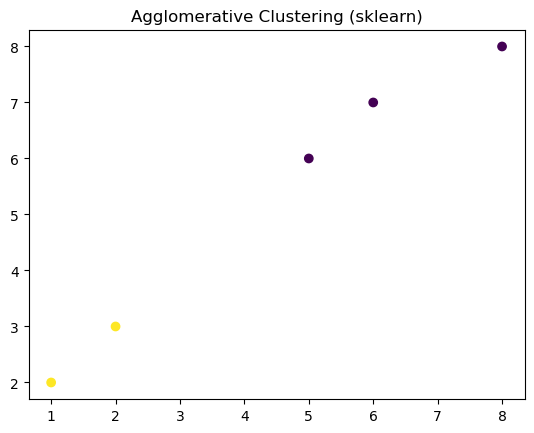

In [5]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Agglomerative Clustering (sklearn)")
plt.show()

In [ ]:
# Divisive  CLustering 

In [6]:
import numpy as np
from sklearn.cluster import KMeans

# Sample data
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [8, 8],
    [9, 9]
])

# Step 1: Split into 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

print("Initial Split:", labels)

Initial Split: [0 0 0 1 1]


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [7]:
# Get points from cluster 0
cluster_0 = X[labels == 0]

# Split cluster 0 again
kmeans2 = KMeans(n_clusters=2, random_state=0)
labels2 = kmeans2.fit_predict(cluster_0)

print("Second Split (Cluster 0):", labels2)

Second Split (Cluster 0): [1 0 0]


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# Whole dataset → split into 2
# Pick a cluster → split again
# Repeat recursively

This creates a tree (top-down)

# How do we decide number of clusters in practice?

In a dendrogram, the horizontal line you draw is basically:

“At what distance do I stop merging clusters?”

So the user is choosing a threshold.

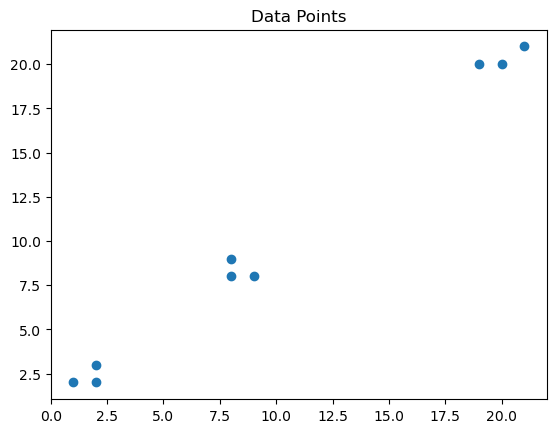

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Create sample data
X = np.array([
    [1, 2], [2, 2], [2, 3],      # Cluster 1
    [8, 8], [9, 8], [8, 9],      # Cluster 2
    [20, 20], [21, 21], [19, 20] # Cluster 3
])

# Plot data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Data Points")
plt.show()

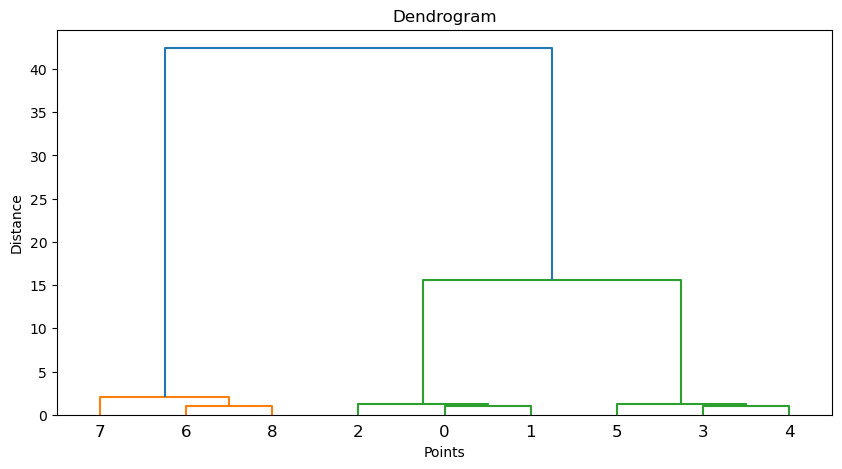

In [12]:
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [13]:
from scipy.cluster.hierarchy import fcluster

# Correct cut (3 clusters)
clusters_correct = fcluster(Z, t=3, criterion='maxclust')

# Too many clusters
clusters_low = fcluster(Z, t=6, criterion='maxclust')

# Too few clusters
clusters_high = fcluster(Z, t=2, criterion='maxclust')

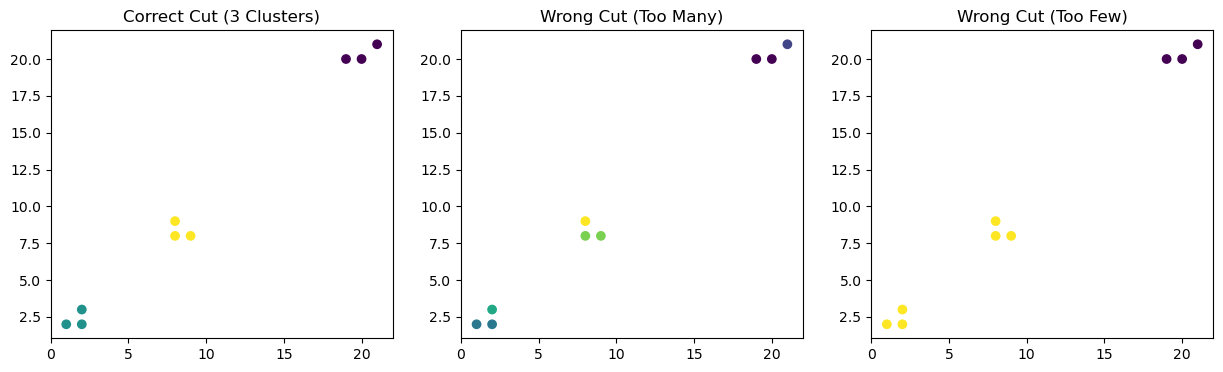

In [14]:
plt.figure(figsize=(15, 4))

# Correct
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=clusters_correct)
plt.title("Correct Cut (3 Clusters)")

# Too many
plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=clusters_low)
plt.title("Wrong Cut (Too Many)")

# Too few
plt.subplot(1, 3, 3)
plt.scatter(X[:, 0], X[:, 1], c=clusters_high)
plt.title("Wrong Cut (Too Few)")

plt.show()

In [ ]:
# Another way of doing it (Which you all know)

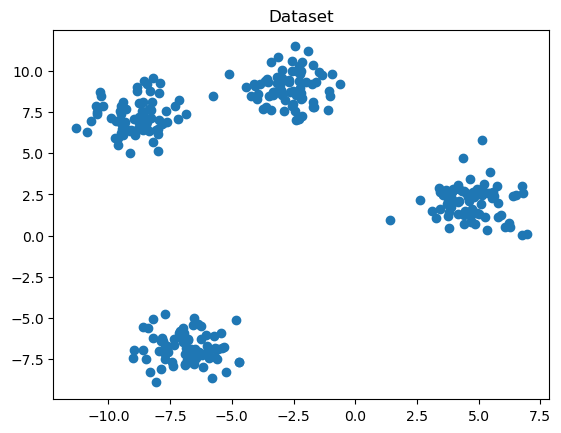

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create synthetic data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Dataset")
plt.show()

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

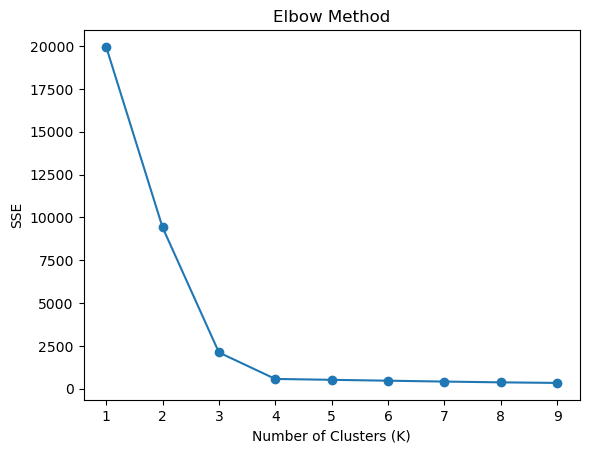

In [24]:
# Elbow 

from sklearn.cluster import KMeans

sse = []

k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # SSE

plt.plot(k_values, sse, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [ ]:
# Look for the “elbow point” (sharp bend) .....Choose K where improvement suddenly slows down 

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

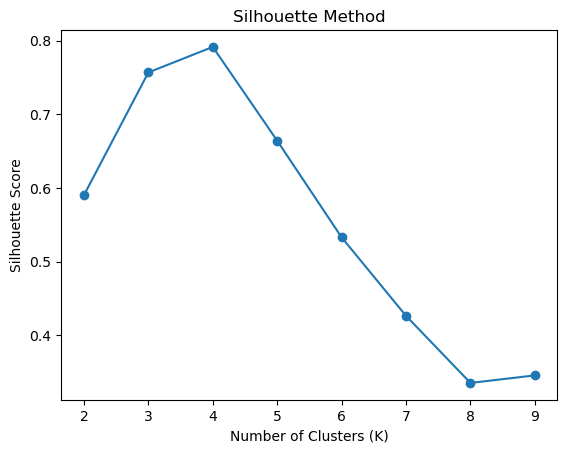

In [25]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 10), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [26]:
# Just showing
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X, method='ward')

for k in range(2, 6):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.5902182019276141
K=3, Silhouette Score=0.7569108532473462
K=4, Silhouette Score=0.7915830011443039
K=5, Silhouette Score=0.6869452569646092


In [ ]:
# Example of HC in some datasets

In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

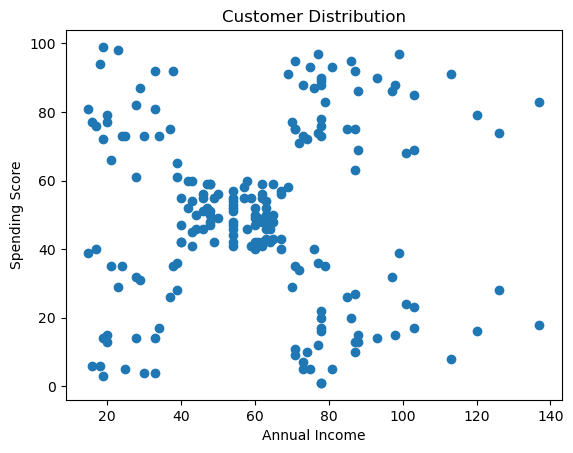

In [18]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

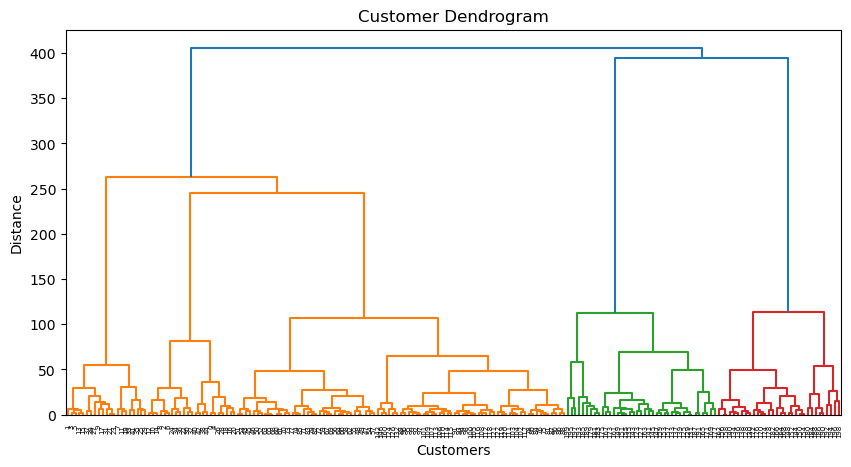

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Customer Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [21]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=5, criterion='maxclust')

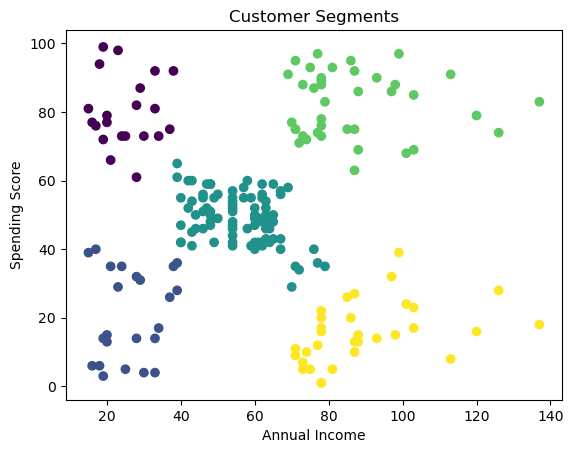

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [ ]:
Some example interpretations which i thought might be meaningful....

High income + high spending → Premium customers
High income + low spending → Careful customers
Low income + high spending → Impulsive buyers
Low income + low spending → Budget customers

In [ ]:
# When to use 

| Scenario                                                 | Use Hierarchical? | Why It Fits                                          |
| -------------------------------------------------------- | ----------------- | ---------------------------------------------------- |
| Number of clusters is **unknown**                        | Yes             | Dendrogram helps decide natural groupings            |
| Need to **understand relationships** between data points | Yes             | Produces a tree (hierarchy), not just flat clusters  |
| Dataset is **small to medium** (≤ few thousand points)   | Yes             | Computationally expensive for large datasets         |
| Need **interpretable results**                           | Yes             | Easy to visualize and explain via dendrogram         |
| Clusters may have **nested structure**                   | Yes             | Captures sub-clusters (hierarchy within clusters)    |
| Early-stage **exploratory data analysis (EDA)**          | Yes             | Helps discover patterns before applying other models |
| Data has **non-spherical clusters**                      | Sometimes       | Works better than K-Means in some irregular cases    |


In [ ]:
# When not to use 

| Scenario                            | Use Hierarchical? | Why Not                                      |
| ----------------------------------- | ----------------- | -------------------------------------------- |
| Dataset is **very large (100k+)**   | No              | Too slow and memory-intensive                |
| Need **real-time clustering**       | No              | Not designed for fast updates                |
| Number of clusters is already known | Prefer K-Means  | Simpler and faster                           |
| Need **scalable production system** | No              | Doesn’t scale well                           |
| Data changes frequently             | No              | No easy way to update clusters incrementally |


In [ ]:
Just a convention:

Use Hierarchical for understanding structure
Use K-Means for scaling and deployment